> Tensorflow Documentation - https://www.tensorflow.org/api_docs/python/

UV is An extremely fast Python package and project manager, faster 10-100x time than pip.
Installing UV, setting Up Virtual Environment and downloading depending dependencies.
```sh
pip install uv
uv venv
uv pip install -r requirements.txt
```

# OpenCV Library

In [9]:
import numpy as np
import caer
import cv2 as cv
import matplotlib.pyplot as plt

## Reading Image & Video

In [2]:
img = cv.imread('Resources/Photos/cat_large.jpg')
cv.imshow('Cat', img)
cv.waitKey(0) # Time Delay

-1

capture = cv.VideoCapture(0) # Device camera

In [3]:
capture = cv.VideoCapture('Resources/Videos/dog.mp4')

while True:
    isTrue, frame = capture.read() # Reads video frame by frame
    cv.imshow('Video', frame)

    # if the letter d is pressed, then break out of this loop and stop displaying the video
    if cv.waitKey(20) & 0xFF==ord('d'):
        break

capture.release() # release capture pointer
cv.destroyAllWindows()

## Resizing & Rescaling

Works for Images, Videos and Live Videos

In [4]:
def rescaleFrame(frame, scale=0.2):
    width = int(frame.shape[1] * scale)
    height = int(frame.shape[0] * scale) 
    dimensions = (width, height)
    return cv.resize(frame, dimensions, interpolation = cv.INTER_AREA) 

In [5]:
capture = cv.VideoCapture('Resources/Videos/dog.mp4')

while True:
    isTrue, frame = capture.read() # Reads video frame by frame

    frame_resized = rescaleFrame(frame)
    cv.imshow('Video Resized', frame_resized)

    # if the letter d is pressed, then break out of this loop and stop displaying the video
    if cv.waitKey(20) & 0xFF==ord('d'):
        break

capture.release() # release capture pointer
cv.destroyAllWindows()

In [6]:
img = cv.imread('Resources/Photos/cat_large.jpg')
img_resized = rescaleFrame(img)
cv.imshow('Cat', img_resized)
cv.waitKey(0) # Time Delay

100

Only works for live videos

In [7]:
def changeRes(width, height):
    capture.set(3, width)
    capture.set(4, height)

## Draw & Write on Images

In [2]:
blank = np.zeros((500,500,3), dtype = 'uint8') # datatype of image is uint8
cv.imshow('Blank', blank)
cv.waitKey(0)

-1

In [ ]:
# 1. Paint the image a certain colour
blank[:] = 0,255,0 # Blue, Green, Red
cv.imshow('Green', blank)
cv.waitKey(0)

-1

In [ ]:
# 2. Paint the image a certain colour in a certain range
blank[200:300, 300:400] = 0,0,255 # Blue, Green, Red
cv.imshow('Green', blank)
cv.waitKey(0)

-1

In [ ]:
# 3. Draw a rectangle
cv.rectangle(blank, (0,0), (250, 500), (255,0,0), thickness = 2)
cv.imshow('Rectangle', blank)
cv.waitKey(0)

-1

In [ ]:
# 4. Draw a solid rectangle
cv.rectangle(blank, (0,0), (250, 500), (0,255,0), thickness = cv.FILLED) # cv.FILLED can be replaced by -1
cv.imshow('Rectangle', blank)
cv.waitKey(0)

-1

In [8]:
# 5. Draw a solid square
blank = np.zeros((500,500,3), dtype = 'uint8')
cv.rectangle(blank, (0,0), (blank.shape[1]//2, blank.shape[0]//2), (0,255,0), thickness = -1)
cv.imshow('Square', blank)
cv.waitKey(0)

-1

In [11]:
# 6. Draw a circle
cv.circle(blank, (blank.shape[1]//2, blank.shape[0]//2), 40, (0,0,255), thickness = -1)
cv.imshow('Circle', blank)
cv.waitKey(0)

-1

In [12]:
# 7. Draw a line

cv.line(blank, (0,0), (blank.shape[1]//2, blank.shape[0]//2), (255,255,255), thickness = 3)
cv.imshow('Line', blank)
cv.waitKey(0)

-1

In [15]:
# 8. Write text
blank = np.zeros((500,500,3), dtype = 'uint8')
cv.putText(blank, 'Hello, my name is Ishaan!!!',(0,225), cv.FONT_HERSHEY_TRIPLEX, 1.0,(0,255,0),2)
cv.imshow('Text', blank)
cv.waitKey(0)

-1

## 6 Essential Functions

In [ ]:
# Original
img = cv.imread('Resources/Photos/park.jpg')
cv.imshow('Park', img)
cv.waitKey(0)

-1

In [11]:
# 1. Converting to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv.imshow('Gray', gray)
cv.waitKey(0)

-1

In [12]:
# 2. Blur
blur = cv.GaussianBlur(img, (7,7), cv.BORDER_DEFAULT)
cv.imshow('Blur', blur)
cv.waitKey(0)

-1

In [ ]:
# 3 A. Edge Cascade

canny = cv.Canny(img, 125, 175)
cv.imshow('Canny Edges', canny)
cv.waitKey(0)

-1

In [17]:
# 3 B. Edge Cascade with reduced edges

canny = cv.Canny(blur, 125, 175) # using blur image
cv.imshow('Canny Edges', canny)
cv.waitKey(0)

-1

In [21]:
# 4. Dilating the image
dilated = cv.dilate(canny, (7,7), iterations = 3)
cv.imshow('Dilated', dilated)
cv.waitKey(0)

-1

In [23]:
# 5. Eroding
eroded = cv.erode(dilated, (7,7), iterations = 3)
cv.imshow('Eroded', eroded)
cv.waitKey(0)

-1

In [ ]:
# 6 A. Resize to lower dimensions 

resized = cv.resize(img, (500,500), interpolation = cv.INTER_AREA)
cv.imshow('Resized', resized)
cv.waitKey(0)

-1

In [ ]:
# 6 B. Resize to higher dimensions.

resized = cv.resize(img, (1000,1000), interpolation = cv.INTER_LINEAR) # or use INTER_CUBIC
cv.imshow('Resized', resized)
cv.waitKey(0)

-1

In [28]:
# 6 C. Cropping

cropped = img[50:200, 200:400]
cv.imshow('Cropped', cropped)
cv.waitKey(0)

-1

## Image Transformations

In [2]:
# Original
img = cv.imread('Resources/Photos/park.jpg')
cv.imshow('Park', img)
cv.waitKey(0)

-1

In [5]:
# 1. Translation
def translate(img, x, y):
    transMat = np.float32([[1,0,x], [0,1,y]])
    dimensions = (img.shape[1], img.shape[0])
    return cv.warpAffine(img, transMat, dimensions)

# -x --> Left ; -y --> Up ; x --> Right ; y --> Down

translated = translate(img, 100, 100)
cv.imshow('Translated', translated)
cv.waitKey(0)

-1

In [8]:
# 2. Rotation

def rotate(img, angle, rotPoint = None):
    (height, width) = img.shape[:2]

    if rotPoint is None:
        rotPoint = (width//2, height//2)

    rotMat = cv.getRotationMatrix2D(rotPoint, angle, 1.0)
    dimensions = (width, height)

    return cv.warpAffine(img, rotMat, dimensions)

rotated = rotate(img, 45) # Anti-clockwise (+ve)
cv.imshow('Rotated', rotated)

rotated_rotated = rotate(rotated, 45)
cv.imshow('Rotated Rotated', rotated_rotated)
cv.waitKey(0)

-1

In [9]:
# 3. Flipping

flip = cv.flip(img, -1) # 0 --> vertically ; 1 --> horizontally ; -1 --> both vertically & horizontally
cv.imshow('Flip', flip)
cv.waitKey(0)

-1

## Contour Detection

In [ ]:
# Original
img = cv.imread('Resources/Photos/cats.jpg')
cv.imshow('Cats', img)
cv.waitKey(0)

-1

In [11]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv.imshow('Gray', gray)
cv.waitKey(0)

-1

In [ ]:
canny = cv.Canny(img, 125, 175)
cv.imshow('Canny Edges', canny)
cv.waitKey(0)

-1

- RETR_TREE for hierarchical contours ; RETR_EXTERNAL or RETR_LIST for all contours
- Approximation method
    - `CHAIN_APPROX_NONE` - Stores absolutely all the contour points (no compression). It retains every single boundary pixel but consumes more memory.
    - `CHAIN_APPROX_SIMPLE` - Compresses horizontal, vertical, and diagonal segments, leaving only their end points. E.g., a straight line or a rectangle is compressed to just its corner/end points, saving memory.

In [ ]:
contours, heirarchies = cv.findContours(canny, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
print(f'{len(contours)} contours found!')

2794 contours found!


In [16]:
blur = cv.GaussianBlur(img, (5,5), cv.BORDER_DEFAULT)
canny_blur = cv.Canny(blur, 125, 175)
cv.imshow('Canny Edges of Blur Image', canny)
cv.waitKey(0)

-1

In [17]:
contours, heirarchies = cv.findContours(canny_blur, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
print(f'{len(contours)} contours found!')

466 contours found!


In [ ]:
ret, thresh = cv.threshold(gray, 125, 255, cv.THRESH_BINARY)
# below 125 turns black, above 125 turns white

cv.imshow('Thresh', thresh)
contours, heirarchies = cv.findContours(thresh, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
print(f'{len(contours)} contours found!')
cv.waitKey(0)

839 contours found!


-1

In [21]:
#blank
blank = np.zeros(img.shape, dtype = 'uint8')
cv.imshow('Blank', blank)
cv.waitKey(0)

-1

In [22]:
# drawing contours
cv.drawContours(blank, contours, -1, (0,0,255), 2) # -1 -> ALL
cv.imshow('Contours Drawn', blank)
cv.waitKey(0)

-1

## Color Spaces

**NOTE** - For any conversions which doesn't have BGR color space , you can directly convert the color first it needs to be converted to BGR using ___2BGR methods and then BGR to the required color space!

In [3]:
# Original
img = cv.imread('Resources/Photos/park.jpg')
cv.imshow('Park', img)
cv.waitKey(0)

-1

In [5]:
# BGR to HSV (Hue Saturation Value)

hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
cv.imshow('HSV', hsv)
cv.waitKey(0)

-1

In [8]:
# BGR to L*a*b

lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
cv.imshow('L*a*b', lab)
cv.waitKey(0)

-1

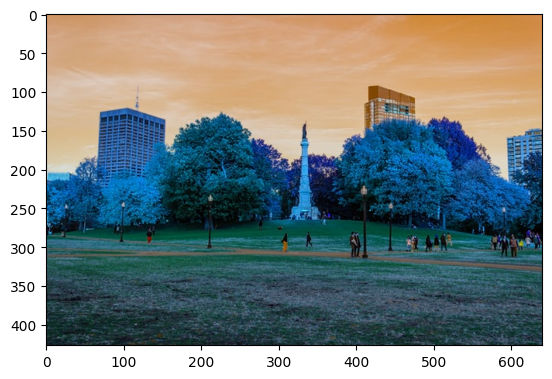

In [ ]:
# Matplotlib uses RGB Display instead of BGR Display

plt.imshow(img)
plt.show()

In [11]:
# BGR to RGB

rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
cv.imshow('RGB', rgb)
cv.waitKey(0)

-1

In [ ]:
# BGR to RGB

rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
cv.imshow('RGB', rgb)
cv.waitKey(0)

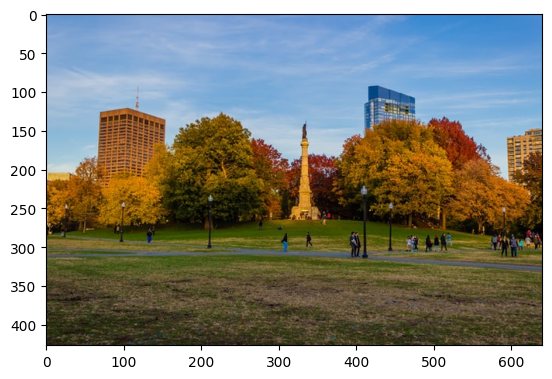

In [ ]:
# Matplotlib inverting rgb to bgr now. ROFL!

plt.imshow(rgb)
plt.show()

## Color Channels

In [ ]:
img = cv.imread('Resources/Photos/park.jpg')
cv.imshow('Park', img)

blank = np.zeros(img.shape[:2], dtype='uint8')

b,g,r = cv.split(img)

blue = cv.merge([b,blank,blank])
green = cv.merge([blank,g,blank])
red = cv.merge([blank,blank,r])

cv.imshow('Blue', blue)
cv.imshow('Green', green)
cv.imshow('Red', red)

print(img.shape)
print(b.shape)
print(g.shape)
print(r.shape)

merged = cv.merge([b,g,r])
cv.imshow('Merged Image', merged)

cv.waitKey(0)

(427, 640, 3)
(427, 640)
(427, 640)
(427, 640)


-1

## Blurring Techniques

1. **Averaging Blur**
    - **How it works:** It takes the average of all the pixels under the kernel area (normalized box filter).
    - **Characteristics:** Simple and fast. Treats all pixels in the kernel area equally.
    - **Disadvantage:** Tends to blur and wash out sharp edges significantly since it lacks weighted scaling.

2. **Gaussian Blur**
    - **How it works:** It uses a Gaussian kernel where pixels closer to the center have higher weights/influence.
    - **Characteristics:** Produces a more natural, smooth blur than simple averaging.
    - **Advantages:** Less edge degradation than averaging; highly effective for noise reduction as a pre-processing step.

3. **Median Blur**
    - **How it works:** Replaces the central pixel with the median of all pixel values under the kernel window.
    - **Characteristics:** Highly effective for removing "salt-and-pepper" (impulse) noise.
    - **Advantages:** Since it selects an actual pixel value from the neighborhood (not a calculated average), it preserves sharp edges much better than Averaging or Gaussian blur.

4. **Bilateral Blur (Bilateral Filtering)**
    - **How it works:** Uses two Gaussian filters - one for space (distance) and one for intensity (color similarity).
    - **Characteristics:** Only blurs pixels that are both spatially close and similar in color/intensity.
    - **Advantages:** Extremely effective at edge-preserving smoothing. Denoises flat surfaces while keeping structural boundaries sharp.
    - **Disadvantages:** Computationally more complex and expensive than the other three blurring methods.

In [17]:
# Original
img = cv.imread('Resources/Photos/cats.jpg')
cv.imshow('Cats', img)
cv.waitKey(0)

-1

In [ ]:
average = cv.blur(img, (3,3))
cv.imshow('Average Blur', average)
cv.waitKey(0)

-1

In [ ]:

gauss = cv.GaussianBlur(img, (3,3), 0)
cv.imshow('Gaussian Blur', gauss)
cv.waitKey(0)

-1

In [ ]:
median = cv.medianBlur(img, 3)
cv.imshow('Median Blur', median)
cv.waitKey(0)

-1

In [ ]:
bilateral = cv.bilateralFilter(img, 10, 35, 25)
cv.imshow('Bilateral', bilateral)
cv.waitKey(0)

-1

## Bitwise Operations

pixel is turned off when value is 0 and on when value is 1

In [22]:
blank = np.zeros((400,400), dtype='uint8')

rectangle = cv.rectangle(blank.copy(), (30,30), (370,370), 255, -1)
circle = cv.circle(blank.copy(), (200,200), 200, 255, -1)

cv.imshow('Rectangle', rectangle)
cv.imshow('Circle', circle)

# bitwise AND --> intersecting regions
bitwise_and = cv.bitwise_and(rectangle, circle)
cv.imshow('Bitwise AND', bitwise_and)

# bitwise OR --> non-intersecting and intersecting regions
bitwise_or = cv.bitwise_or(rectangle, circle)
cv.imshow('Bitwise OR', bitwise_or)

# bitwise XOR --> non-intersecting regions
bitwise_xor = cv.bitwise_xor(rectangle, circle)
cv.imshow('Bitwise XOR', bitwise_xor)

# bitwise NOT
bitwise_not = cv.bitwise_not(circle)
cv.imshow('Circle NOT', bitwise_not)

cv.waitKey(0)

-1

## Masking

In [23]:
img = cv.imread('Resources/Photos/cats 2.jpg')
cv.imshow('Cats', img)

blank = np.zeros(img.shape[:2], dtype='uint8')
cv.imshow('Blank Image', blank)

circle = cv.circle(blank.copy(), (img.shape[1]//2 + 45,img.shape[0]//2), 100, 255, -1)

rectangle = cv.rectangle(blank.copy(), (30,30), (370,370), 255, -1)

weird_shape = cv.bitwise_and(circle,rectangle)
cv.imshow('Weird Shape', weird_shape)

masked = cv.bitwise_and(img,img,mask=weird_shape)
cv.imshow('Weird Shaped Masked Image', masked)

cv.waitKey(0)

-1

## Histograms

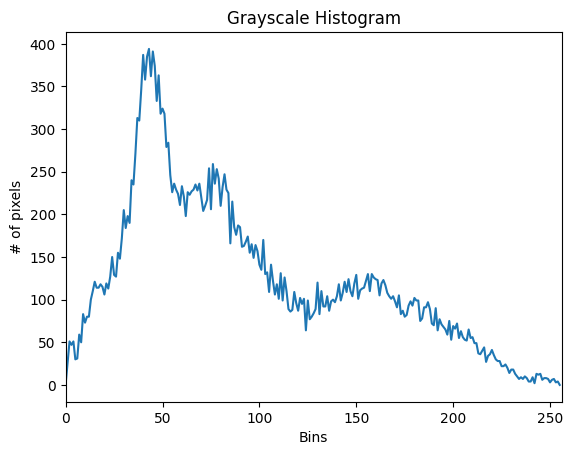

-1

In [25]:
img = cv.imread('Resources/Photos/cats.jpg')
cv.imshow('Cats', img)

blank = np.zeros(img.shape[:2], dtype='uint8')

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv.imshow('Gray', gray)

mask = cv.circle(blank, (img.shape[1]//2,img.shape[0]//2), 100, 255, -1)

masked = cv.bitwise_and(img,img,mask=mask)
cv.imshow('Mask', masked)

# Grayscale histogram
gray_hist = cv.calcHist([gray], [0], mask, [256], [0,256] )

plt.figure()
plt.title('Grayscale Histogram')
plt.xlabel('Bins')
plt.ylabel('# of pixels')
plt.plot(gray_hist)
plt.xlim([0,256])
plt.show()

cv.waitKey(0)

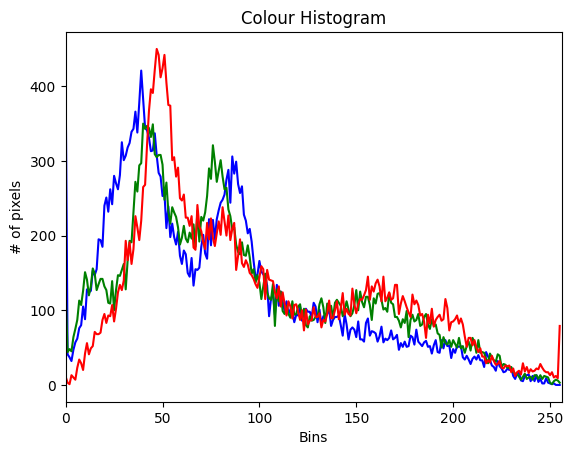

-1

In [26]:
# Colour Histogram

plt.figure()
plt.title('Colour Histogram')
plt.xlabel('Bins')
plt.ylabel('# of pixels')
colors = ('b', 'g', 'r')
for i,col in enumerate(colors):
    hist = cv.calcHist([img], [i], mask, [256], [0,256])
    plt.plot(hist, color=col)
    plt.xlim([0,256])

plt.show()
cv.waitKey(0)

## Thresholding

In [27]:
img = cv.imread('Resources/Photos/cats.jpg')
cv.imshow('Cats', img)

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv. imshow('GRay', gray)

# Simple Thresholding
threshold, thresh = cv.threshold(gray, 150, 255, cv. THRESH_BINARY )
cv. imshow('Simple Thresholded', thresh)

cv.waitKey(0)

-1

In [28]:
threshold, thresh_inv = cv.threshold(gray, 150, 255, cv. THRESH_BINARY_INV )
cv. imshow('Simple Thresholded Inverse', thresh_inv)

cv.waitKey(0)

-1

In [33]:
# Adaptive Thresholding

adaptive_thresh = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, 3)
cv. imshow('Adaptive Thresholding Mean', adaptive_thresh)

adaptive_thresh = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 3)
cv. imshow('Adaptive Thresholding Gaussian', adaptive_thresh)

cv.waitKey(0)

-1

## Edge Detection

In [36]:
img = cv.imread('Resources/Photos/park.jpg')
cv.imshow('Park', img)

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv.imshow('Gray', gray)

# Laplacian
lap = cv.Laplacian(gray, cv.CV_64F)
lap = np.uint8(np.absolute(lap))
cv. imshow('Laplacian', lap)

cv.waitKey(0)

-1

In [37]:
# Sobel
sobelx = cv.Sobel(gray, cv.CV_64F,1,0)
sobely = cv.Sobel(gray, cv.CV_64F,0,1)
combined_sobel = cv.bitwise_or(sobelx, sobely)

cv.imshow('Sobel X', sobelx)
cv. imshow('Sobel Y', sobely)
cv. imshow('Combined Sobel', combined_sobel)

cv.waitKey(0)

-1